# Figure1: plotting and resource-data code

This notebook contains the original figure-production cells. Inputs are under `data/Figure1/`; outputs may be written to `output/`.

## Resource-data sheets included for this figure

- `Figure_1b_patient_sequencing_summary` — resource-data sheet for the corresponding panel.
- `Figure_1d_major_cell_type_proportions` — resource-data sheet for the corresponding panel.
- `Figure_1e_cell_type_tree_counts` — resource-data sheet for the corresponding panel.
- `Figure_1e_tree_edges` — resource-data sheet for the corresponding panel.

The final resource tables use `NR` as the non-responder label. The original analysis cells are retained so that their complete plotting logic is traceable.

In [26]:
# Harmonize standalone response labels at input time: PR -> NR.
harmonize_nr_labels <- function(x) {
  normalize_df <- function(df) {
    for (nm in names(df)) {
      if (is.character(df[[nm]]) || is.factor(df[[nm]])) {
        df[[nm]] <- gsub("\bPR\b", "NR", as.character(df[[nm]]), perl = TRUE)
      }
    }
    df
  }
  if (is.data.frame(x)) return(normalize_df(x))
  if (isS4(x) && "meta.data" %in% slotNames(x)) {
    x@meta.data <- normalize_df(x@meta.data)
  }
  x
}


# Figure 1 plotting code\n\nOrganized copy of the manuscript plotting notebook. This standalone notebook runs from `code/`; inputs are in `../data/` and outputs are written to `../output/`. Large inputs are relative symbolic links, described in `../../data/DATA_INPUT_MANIFEST.tsv`.\n

# figure 1 vlz

- kernel: r_env, R 4.1.3

## load

In [27]:
library(tidyverse)
library(tools)
if (requireNamespace("logging", quietly = TRUE)) { library(logging); logging::basicConfig() } else { loginfo <- function(...) invisible(NULL) }
library(ggpubr)
library(ggsci)
library(patchwork)
library(igraph)
library(ggraph)
library(Seurat)

source('shared/r_funcs.r')

theme_set(theme_pubr())

options(warn = -1)

outdir <- "../output"
create_dir(outdir)

In [28]:
f_pat_gp <- '../data/Figure1/tables/patient_info_v2.tsv'
gp <- 'response'

gp_comp_map$response <- list(
  c('R-pre', 'R-post'),
  c('NR-pre', 'NR-post'),
  c('R-pre', 'NR-pre'),
  c('R-post', 'NR-post')
)
gp_lvls$response <- c('R', 'NR')
comb_order <- c('R-pre', 'R-post', 'NR-pre', 'NR-post')

## 1b: clinical info

- date: 2024-01-02
- desc: WES only include TN-paired, Fresh, nonLN samples

In [29]:
outdir <- "../output"
create_dir(outdir)

df_samp <- read_tsv('../data/Figure1/figures/fig1/fig1b-clin_info-wes_tn_pair_fresh_t.tsv')


loginfo('total valid samples: %g', nrow(df_samp))
table(df_samp$tissue_cat, df_samp$data_cat)

Rows: 179 Columns: 12
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (12): patient_id, mandard_group, response_degree, treatment_group, patie...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


2026-07-17 22:47:01.708445 INFO::total valid samples: 179


       
        single-cell WES
  Blood           0  45
  Tumor          81  53

In [30]:
# Optional Fig. 1b Venn panel. The remaining notebook can run without this CRAN package.
if (requireNamespace("venn", quietly = TRUE)) {
    # WES & scRNA tumor samples overlap
    pdf(str_glue('{outdir}/fig1b-venn_clin-wes_vs_sc.pdf'), width = 5, height = 3)
    par(mfrow = c(1, 2), mar = c(0, 0, 0, 0))
    for (stype in c('Baseline', 'Treat')) {
        venn::venn(
            x = list(WES = filter(df_samp, sample_type == stype, data_cat == 'WES', tissue_cat == 'Tumor') %>% pull(sample_id),
                     scRNA = filter(df_samp, sample_type == stype, data_cat == 'single-cell', tissue_cat == 'Tumor') %>% pull(sample_id)),
            zcolor = 'style', ilcs = 1, sncs = 1, main = stype, line = -2, box = F, par = F, ilabels = 'counts'
        )
    }
    fig1b_venn_plot <- recordPlot()
    dev.off()
    # 在当前 notebook 中显示保存的图。
    replayPlot(fig1b_venn_plot)
} else {
    message("SKIPPED Fig. 1b Venn panel: install the CRAN package `venn` to render it.")
}


In [31]:
# 1. Venn diagram：每个肿瘤样本是否包含 WES/scRNA-seq
fig1b_venn_source <- df_samp %>%
    filter(
        tissue_cat == 'Tumor',
        data_cat %in% c('WES', 'single-cell'),
        sample_type %in% c('Baseline', 'Treat')
    ) %>%
    select(
        patient_id,
        patient,
        response,
        sample_id,
        sample_type,
        tissue_cat,
        data_cat
    ) %>%
    distinct() %>%
    mutate(present = TRUE) %>%
    pivot_wider(
        id_cols = c(
            patient_id,
            patient,
            response,
            sample_id,
            sample_type,
            tissue_cat
        ),
        names_from = data_cat,
        values_from = present,
        values_fill = FALSE
    ) %>%
    rename(
        WES = WES,
        scRNA_seq = `single-cell`
    ) %>%
    mutate(
        venn_region = case_when(
            WES & scRNA_seq  ~ 'WES and scRNA-seq',
            WES             ~ 'WES only',
            scRNA_seq       ~ 'scRNA-seq only',
            TRUE            ~ NA_character_
        ),
        sample_stage = case_match(
            sample_type,
            'Baseline' ~ 'pre',
            'Treat'    ~ 'post',
            .default   = sample_type
        )
    ) %>%
    arrange(sample_type, venn_region, patient_id, sample_id)

write_tsv(
    fig1b_venn_source,
    str_glue(
        '{outdir}/fig1b-venn_wes_scrna_tumor_sample_membership.tsv'
    )
)

In [32]:
# scRNA clinical info barplot
dp <- df_samp %>% 
    filter(data_cat == 'single-cell') %>%
    pivot_wider(id_cols = c('patient_id', gp),
                names_from = 'sample_type',
                values_from = 'sample_id') %>% 
    mutate(sample_cat = case_when(
        !is.na(Baseline) & !is.na(Treat) ~ 'Paired',
        is.na(Baseline) ~ 'Post-only',
        is.na(Treat) ~ 'Pre-only'
    )) %>% 
    count(sample_cat, .data[[gp]], name = 'n_patient') %>% 
    mutate(pat_gp = if_else(is.na(.data[[gp]]), 'unknown', .data[[gp]]),
           sample_cat = factor(sample_cat, levels = c('Paired', 'Pre-only', 'Post-only')))

In [33]:
write_tsv(
    dp,
    str_glue(
        '{outdir}/fig1b-scrna_patient_sampling_counts.tsv'
    )
)

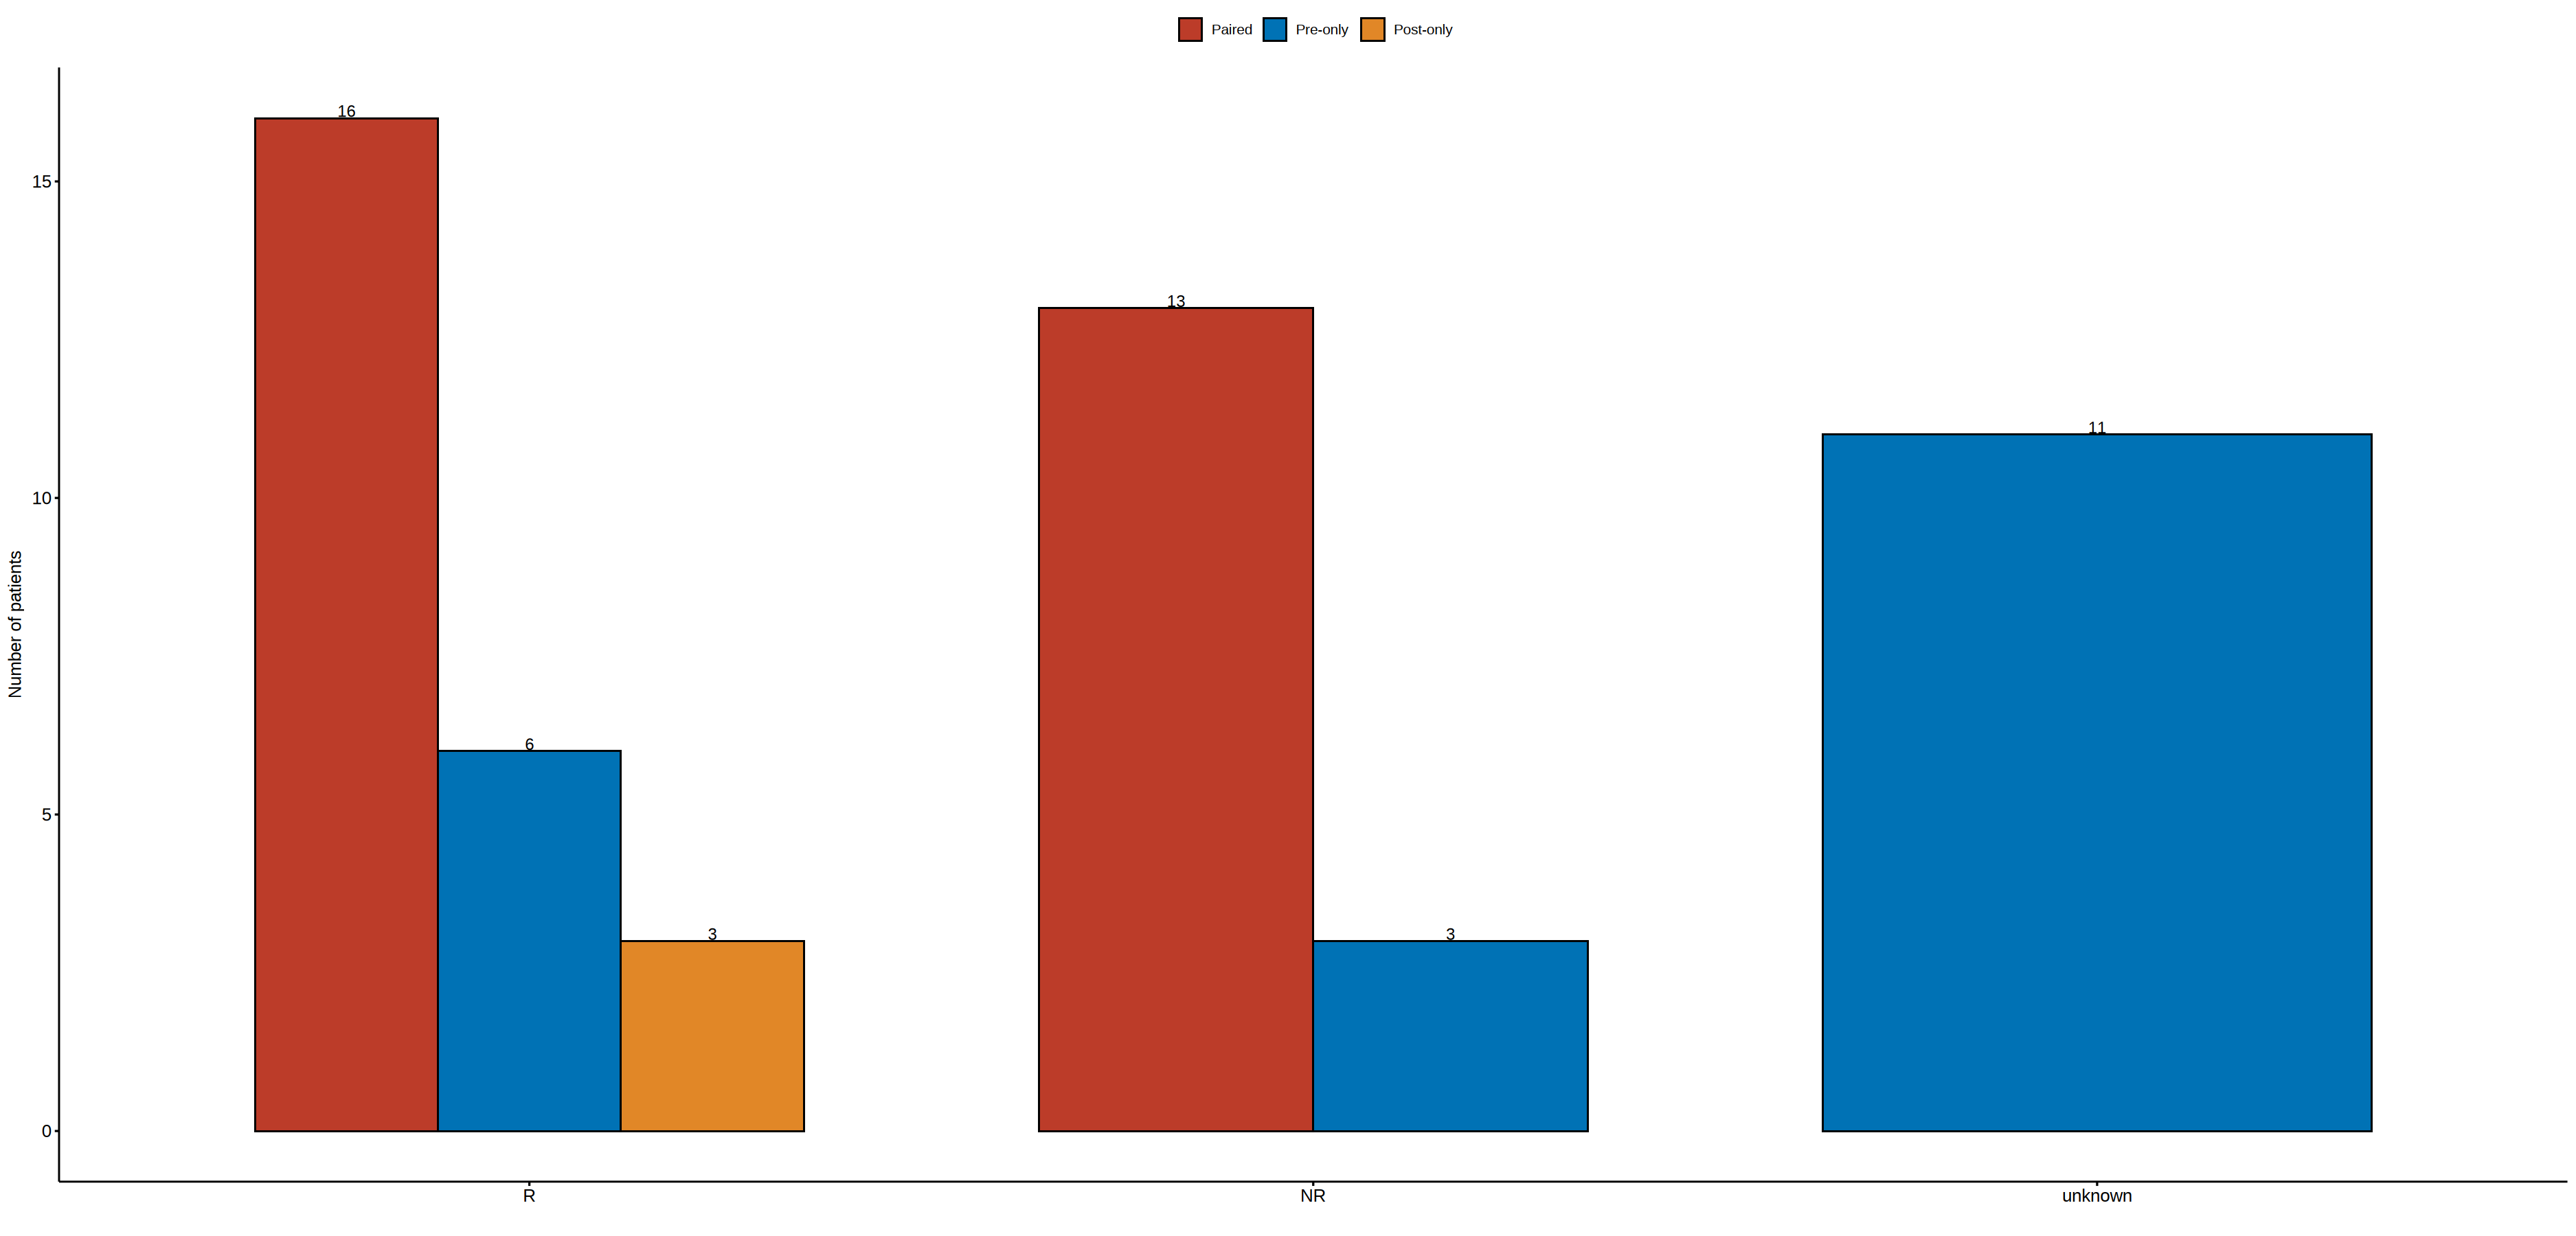

In [34]:
p <- ggbarplot(data = dp, x = 'pat_gp', y = 'n_patient', fill = 'sample_cat', 
               palette = 'nejm', order = c('R', 'NR', 'unknown'),
               position = position_dodge(0.7), label = T, lab.vjust = -0.1) +
    labs(x = '', y = 'Number of patients', fill = '')
ggsave(filename = str_glue('{outdir}/fig1b-bar_clin-{gp}.pdf'), plot = p, width = 5, height = 4)
# 在当前 notebook 中显示最后生成的图。
p


## 1c: umap of whole data (get the data from GEO)

In [ ]:
theme_set(theme_pubr())
outdir <- "../output"

scrna <- harmonize_nr_labels(readRDS('../external_data/GSE314906/whole.rds'))
# GSE314906's current object names the corrected major-cell annotation
# `cell_type_correct`; legacy versions used `cellgp`. Keep the legacy
# plotting field as a non-destructive alias for reproducibility.
if (!'cellgp' %in% colnames(scrna@meta.data)) {
    stopifnot('cell_type_correct' %in% colnames(scrna@meta.data))
    scrna$cellgp <- scrna$cell_type_correct
}

In [ ]:
subdata <- subset(x = scrna, downsample = 10000)
p <- DimPlot(subdata, group.by = 'cellgp', pt.size = 0.8, label = T) +
    NoLegend() + 
    scale_color_jama() +
    theme(plot.title = element_blank())
ggsave(str_glue('{outdir}/fig1c-umap_celltype-whole.pdf'), plot=p, height = 4, width = 5)
# 在当前 notebook 中显示最后生成的图。
p


## 1d: major cell type cell composition

In [36]:
theme_set(theme_pubr())
outdir <- "../output"
f_fig1d <- '../data/Figure1/core_inputs/Figure_1d_major_cell_type_proportions.tsv'


In [37]:
# Directly use the panel-level Source Data rather than cell-level whole_obs.csv.
comp <- read_tsv(f_fig1d, show_col_types = FALSE) %>%
    mutate(cell_type = case_when(
        cell_type == 'T' ~ 'T cells',
        cell_type == 'B' ~ 'B cells',
        TRUE ~ cell_type
    ))
comp %>% write_tsv(str_glue('{outdir}/fig1d-cc-major.tsv'))

# A tibble: 10 × 14
   cell_type   group1 group2  comparison_order paired    n1    n2 n_pairs
   <fct>       <chr>  <chr>              <int> <lgl>  <int> <int>   <int>
 1 Endothelial R-pre  R-post                 1 FALSE     22    19      NA
 2 Endothelial NR-pre NR-post                2 FALSE     16    13      NA
 3 Fibroblast  R-pre  R-post                 1 FALSE     22    19      NA
 4 Fibroblast  NR-pre NR-post                2 FALSE     16    13      NA
 5 Myeloid     R-pre  R-post                 1 FALSE     22    19      NA
 6 Myeloid     NR-pre NR-post                2 FALSE     16    13      NA
 7 Plasma      R-pre  R-post                 1 FALSE     22    19      NA
 8 Plasma      NR-pre NR-post                2 FALSE     16    13      NA
 9 T cells     R-pre  R-post                 1 FALSE     22    19      NA
10 T cells     NR-pre NR-post                2 FALSE     16    13      NA
# ℹ 6 more variables: statistic_W <dbl>, p_raw <dbl>, p_adj <dbl>,
#   p_display <dbl>, labe

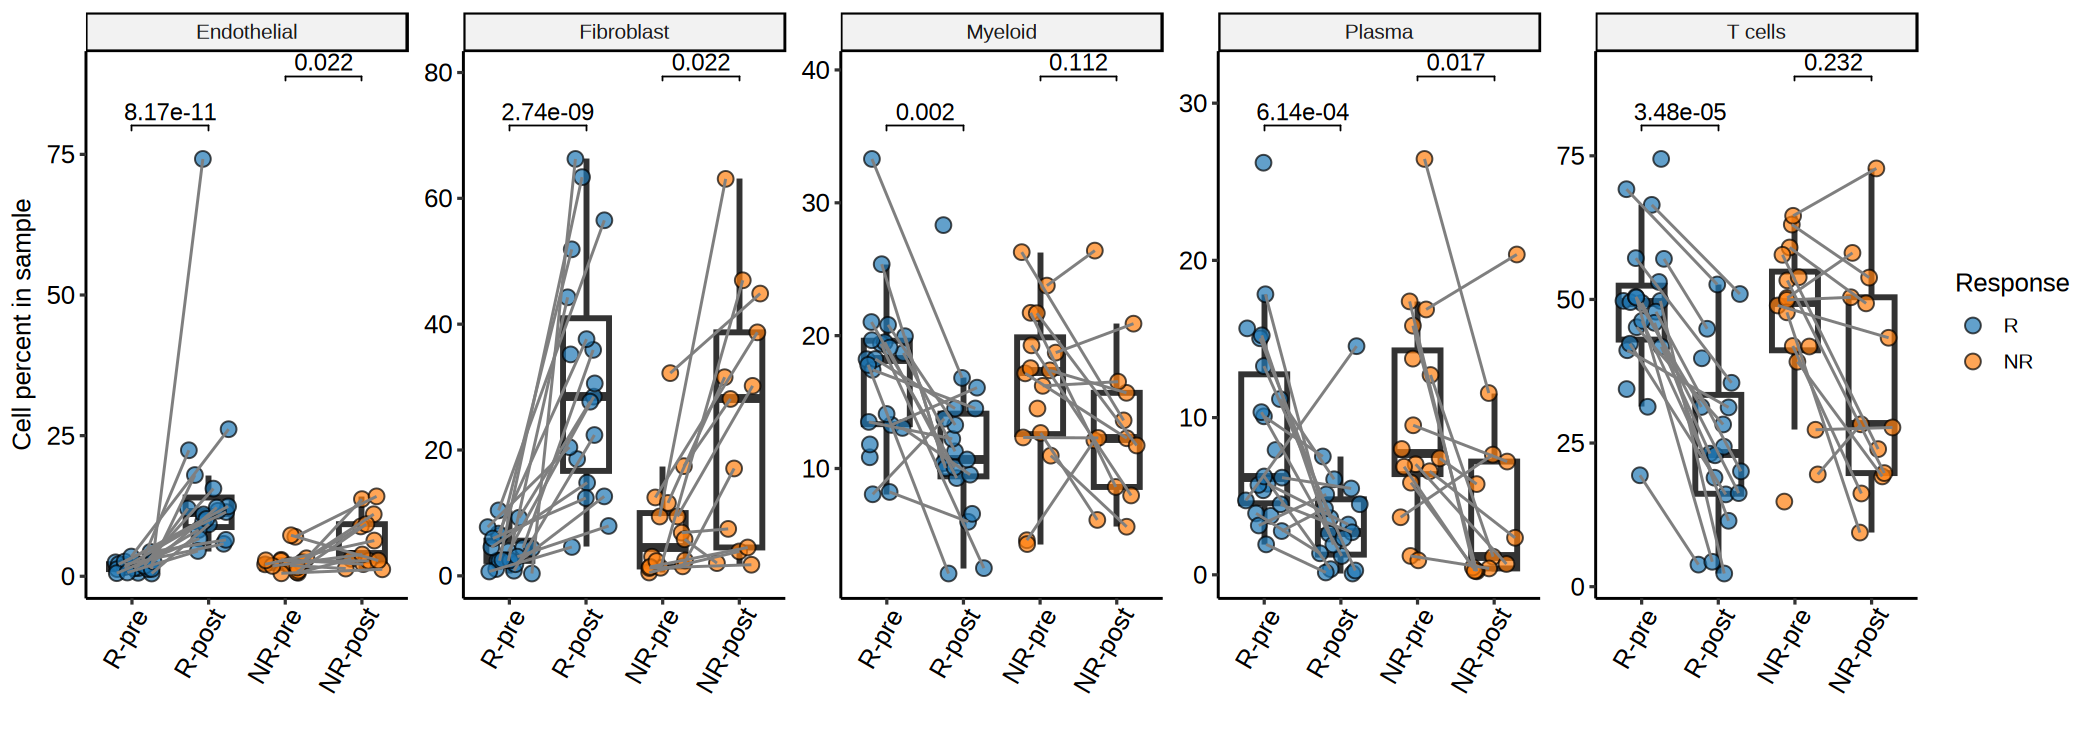

In [38]:

ctype_order <- c('Endothelial', 'Fibroblast', 'Myeloid', 'Plasma', 'T cells')
p <- read_tsv(str_glue('{outdir}/fig1d-cc-major.tsv'), show_col_types = F) %>% 
    filter(.data[[gp]] %in% gp_lvls[[gp]]) %>% 
    filter(cell_type %in% ctype_order) %>% 
    mutate(cell_type = factor(cell_type, ctype_order)) %>% 
    cell_comp_boxplot(x = c(gp, 'sample_type'), y = 'pct', pt_fill = gp,
                      xorder = comb_order, fill_order = gp_lvls[[gp]], xangle = 60, ncol = 7)  +
    labs(fill = 'Response', y = 'Cell percent in sample') +
    theme(legend.position = 'right')
p <- configure_panel_wilcox(
    p,
    x = 'plot_x', y = 'pct',
    comparisons = list(c('R-pre', 'R-post'), c('NR-pre', 'NR-post')),
    facet_by = 'cell_type',
    use_paired = FALSE,
    pair_by = 'patient',
    apply_correction = TRUE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)
ggsave(filename = str_glue('{outdir}/fig1d-box_cc-major.pdf'), 
       plot = p, width = 14, height = 4)
# 在当前 notebook 中显示最后生成的图。

options(repr.plot.width = 14, repr.plot.height = 5, repr.plot.res = 150)
p


## 1e: overview of all subtypes

In [39]:
theme_set(theme_void())
f_tree_counts <- '../data/Figure1/core_inputs/Figure_1e_cell_type_tree_counts.tsv'
f_tree_edges <- '../data/Figure1/core_inputs/Figure_1e_tree_edges.tsv'
f_response_comp <- '../data/Figure1/core_inputs/Figure_1e_subtype_response_composition.tsv'
f_sample_comp <- '../data/Figure1/core_inputs/Figure_1e_subtype_sample_type_composition.tsv'


In [40]:
# Directly use the four Figure 1e Source Data tables.
tree_counts <- read_tsv(f_tree_counts, show_col_types = FALSE)
uniq_major_ctype <- unique(tree_counts$major_cell_type)
major_color_map <- pal_nejm()(length(uniq_major_ctype))
names(major_color_map) <- uniq_major_ctype
uniq_leaf <- unique(tree_counts$subtype)
leaf_colors <- if (exists('scanpy_pal') && !is.null(scanpy_pal$godsnot_102)) {
    scanpy_pal$godsnot_102
} else {
    scales::hue_pal(l = 65, c = 100)(length(uniq_leaf))
}
leaf_color_map <- leaf_colors[seq_along(uniq_leaf)]
names(leaf_color_map) <- uniq_leaf

In [41]:
# Tree topology is supplied as Source Data.
tree_edge <- read_tsv(f_tree_edges, show_col_types = FALSE) %>%
    transmute(from, to, edge_color = major_cell_type) %>%
    distinct() %>% arrange(from, to)
tree_node <- data.frame(name = unique(c(tree_edge$from, tree_edge$to))) %>%
    mutate(node_color = if_else(name %in% names(leaf_color_map), name, NA_character_))

In [42]:
# cluster tree
p_tree <- ggraph(graph = graph_from_data_frame(d = tree_edge, vertices = tree_node), layout = 'dendrogram') +
    geom_edge_link(aes(edge_color = edge_color), edge_width = 1) + 
    geom_node_point(aes(color = node_color), size = 5, alpha = 0.7) + 
    geom_node_text(aes(label = name), repel = T, vjust = 0.5, hjust = 0, 
                   nudge_y = if_else(tree_node$name %in% names(leaf_color_map), 0.5, 0)) +   
    scale_edge_color_manual(values = major_color_map, na.value = 'black') +
    scale_color_manual(values = leaf_color_map, na.value = 'black') +
    coord_flip() +
    scale_y_reverse() + 
    theme(legend.position = "none")

In [43]:
# obtain y coordinates of each leaf
leaf_coord <- p_tree$data %>% 
    filter(name %in% names(leaf_color_map)) %>%
    select(leaf = name, yval = x)

In [44]:
# Cell-count barplot from Source Data.
cell_cnt <- tree_counts %>%
    transmute(color_by = major_cell_type, count_by = subtype, cell_num = cell_count) %>%
    merge(leaf_coord, by.x = 'count_by', by.y = 'leaf')
p_cell_cnt <- ggplot(data = cell_cnt, aes(x = cell_num, y = yval, fill = color_by)) +
    geom_bar(stat = 'identity', show.legend = FALSE, orientation = 'y') +
    scale_fill_manual(values = major_color_map) + labs(title = 'cell count')

In [45]:
# Within-major-cell-type fractions from Source Data.
cell_frac <- tree_counts %>%
    transmute(macrotype = major_cell_type, subtype, color_by = major_cell_type,
              n_cell_macro = major_cell_type_total, n_cell_subtype = cell_count,
              fraction = percent_within_major) %>%
    merge(leaf_coord, by.x = 'subtype', by.y = 'leaf')
p_cell_frac <- ggplot(data = cell_frac, aes(x = fraction, y = yval, fill = color_by)) +
    geom_bar(stat = 'identity', show.legend = FALSE, orientation = 'y') +
    scale_fill_manual(values = major_color_map) + labs(title = 'cell fraction')

In [46]:
# Response composition by subtype from Source Data.
pat_color_map <- c('R' = '#0073C2FF', 'NR' = '#EFC000FF', 'unknown' = 'gray50')
clin_gp_composition <- read_tsv(f_response_comp, show_col_types = FALSE) %>%
    transmute(celltype = subtype, color_by = factor(response_group, levels = names(pat_color_map)), n_cell = cell_count) %>%
    merge(leaf_coord, by.x = 'celltype', by.y = 'leaf')
p_pat_cc <- ggplot(data = clin_gp_composition, aes(x = n_cell, y = yval, fill = color_by)) +
    geom_bar(stat = 'identity', orientation = 'y', position = 'fill') +
    scale_fill_manual(values = pat_color_map) + labs(title = 'response group', fill = '') +
    guides(fill = guide_legend(ncol = 1)) + theme(legend.position = 'top', legend.justification = 'left')

In [47]:
# Sample-type composition by subtype from Source Data.
samp_gp_composition <- read_tsv(f_sample_comp, show_col_types = FALSE) %>%
    transmute(celltype = subtype, color_by = factor(sample_type_plot, levels = c('pre', 'post')), n_cell = cell_count) %>%
    merge(leaf_coord, by.x = 'celltype', by.y = 'leaf')
p_samp_cc <- ggplot(data = samp_gp_composition, aes(x = n_cell, y = yval, fill = color_by)) +
    geom_bar(stat = 'identity', orientation = 'y', position = 'fill') +
    scale_fill_nejm() + labs(title = 'sample type', fill = '') +
    guides(fill = guide_legend(ncol = 1)) + theme(legend.position = 'top', legend.justification = 'left')

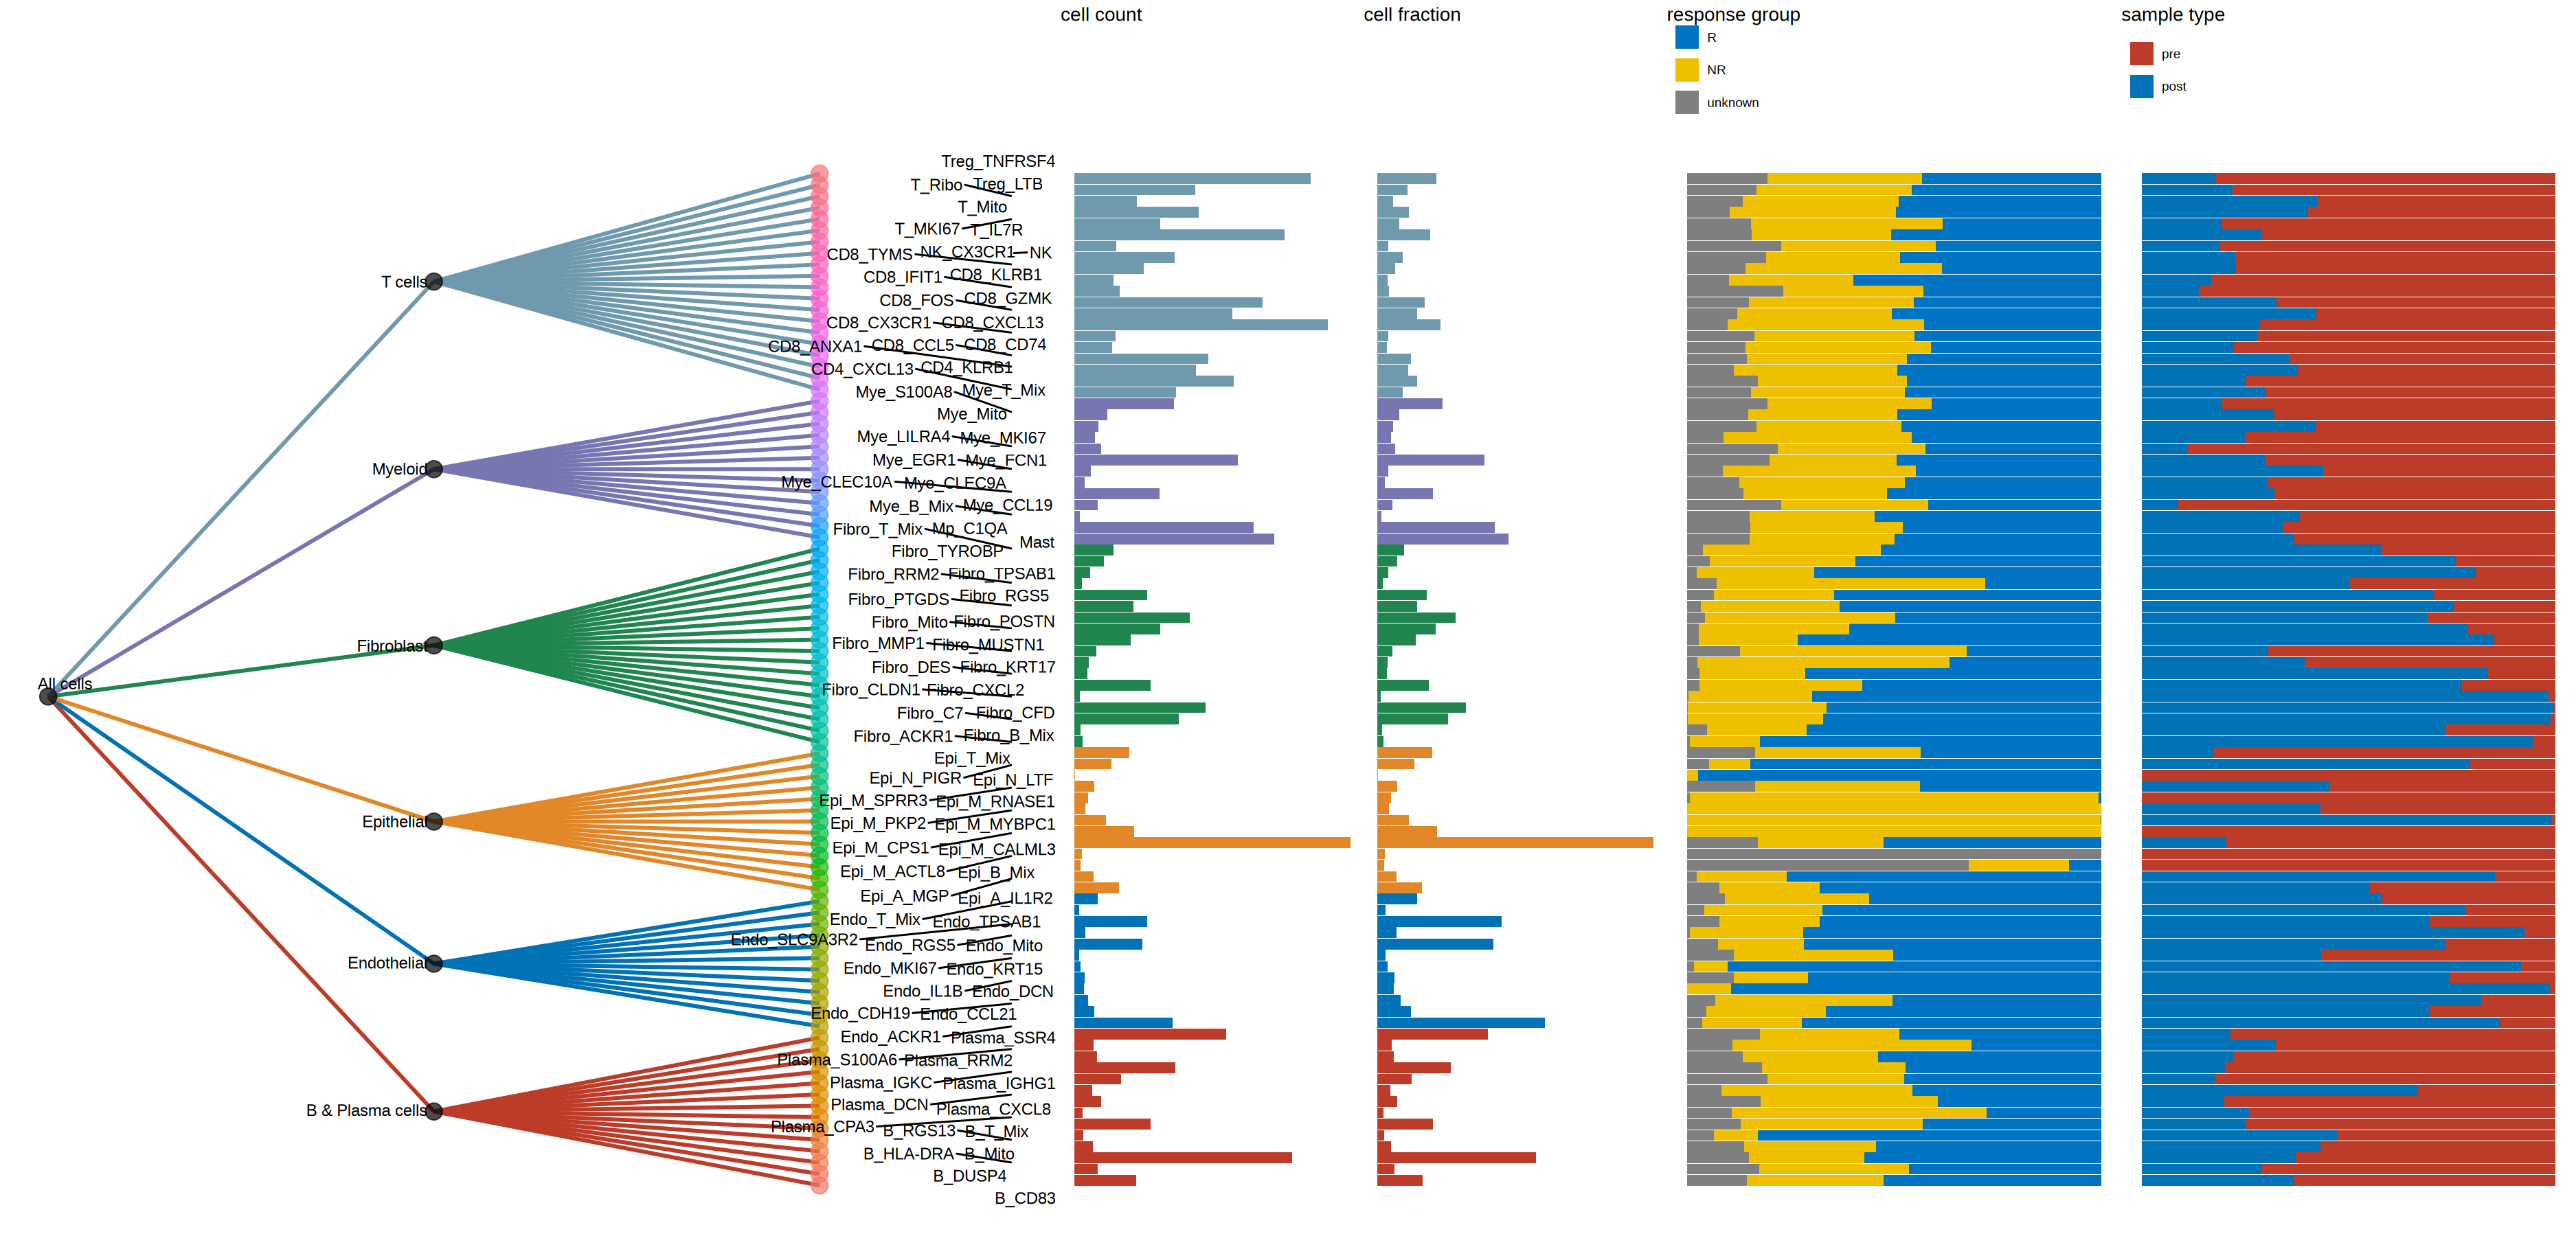

In [48]:
p <- p_tree + p_cell_cnt + p_cell_frac + p_pat_cc + p_samp_cc + 
    plot_layout(nrow = 1, widths = c(3.5, 1, 1, 1.5, 1.5))
ggsave(filename = str_glue('{outdir}/fig1e-subtype_overview.pdf'), height = 25, width = 12, plot = p)
# 在当前 notebook 中显示最后生成的图。

options(repr.plot.width = 25, repr.plot.height = 12, repr.plot.res = 150)
p


## Export the final core resource data